# 01 - Golden-file regression

Runs one fixed accDM model and compares its background, derived parameters, lensed C_ℓ and P(k) with
the stored reference in `golden/`. Any deviation above tolerance fails the notebook. This catches
silent numerical changes from edits to the C code.

`MODE`: `'auto'` checks against the reference, writing it first if missing; `'generate'` rewrites it
(only after a vetted physics change, then commit `golden/`); `'check'` always compares.

The model uses the code's defaults, so a change of default (as for the DE sink on 2026-10-08) also
fails here and needs a regenerated reference.

In [1]:
import hashlib
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from classy import Class

from accdm_nb import plot_style

plot_style()

MODE = 'auto'
GOLDEN_NPZ = Path('golden/regression_accDM.npz')
GOLDEN_JSON = Path('golden/regression_accDM.json')
TOL = {'scalar': 1e-4, 'bg': 1e-4, 'cl': 1e-3, 'pk': 1e-3}     # relative
LMAX = 2500

## Model

Planck 2018 with m = 10¹¹ GeV, f_acc = 0.1, κ = 12.1, a_t = 0.133 and the default kick η = 1. ω_cdm is
lowered so that stable + parent CDM at recombination matches Planck. Changing anything here changes
the fingerprint, and the check then warns that a mismatch is expected.

In [2]:
mass, f_acc, kappa, a_t = 1e11, 0.1, 12.1, 0.133
a_rec = 1/1091
omega_cdm = 0.12011*(1 + f_acc*(1 - a_rec**kappa)/(1 + (a_rec/a_t)**kappa))**(-1)

full_params = {
    'omega_b': 0.022383, 'omega_cdm': omega_cdm, 'H0': 67.32,
    'A_s': 2.1005829616811546e-9, 'n_s': 0.96605, 'tau_reio': 0.0543,
    'output': 'tCl,pCl,lCl,mPk', 'lensing': 'yes', 'l_max_scalars': LMAX,
    'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0,
    'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t, 'f_acc': f_acc,
    'm_acc_in_GeV': mass, 'm_cdm_in_GeV': mass,
    'N_ncdm': 2, 'deg_ncdm': '3, 1', 'm_ncdm': f'0.02, {mass}*1e9', 'T_ncdm': '0.71611, 1',
    'N_ur': 0.0046, 'ncdm_quadrature_strategy': '0, 5',
    'reionization_z_start_max': 80, 'evolver': 0, 'background_Nloga': 40000,
    'ncdm_fluid_approximation': 3,
}
PARAM_HASH = hashlib.md5(json.dumps(full_params, sort_keys=True, default=str).encode()).hexdigest()[:12]
print('parameter fingerprint:', PARAM_HASH)

parameter fingerprint: 796aedfefaa9


## Run

The background is read at fixed redshifts and P(k) at fixed k, so the reference does not depend on
CLASS's internal sampling. Ω_acc is the daughter density today.

In [3]:
Z_NODES = np.array([0, 0.5, 1, 2, 5, 10, 30, 100, 300, 1000, 3e3, 1e4, 1e5, 1e6])
K_NODES = np.logspace(-3, 0.7, 40)      # 1/Mpc


def at_z(bg, col):
    z = np.asarray(bg['z'])
    order = np.argsort(z)
    return np.interp(Z_NODES, z[order], np.asarray(bg[col])[order])


M = Class()
M.set(full_params)
M.compute()
bg = M.get_background()
scalars = {k: float(v) for k, v in M.get_current_derived_parameters(
    ['sigma8', 'Omega_m', 'h', '100*theta_s', 'z_reio', 'age', 'A_s']).items()}
scalars['Omega_acc'] = float(bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1])
cl = M.lensed_cl(LMAX)
result = {'cl_' + s: np.asarray(cl[s]) for s in ('tt', 'te', 'ee', 'pp')}
result.update(ell=np.asarray(cl['ell']), pk=np.array([M.pk(k, 0.0) for k in K_NODES]),
              bg_H=at_z(bg, 'H [1/Mpc]'), bg_rho_acc_cdm=at_z(bg, '(.)rho_acc_cdm'),
              bg_rho_daughter=at_z(bg, '(.)rho_ncdm[1]'))
M.struct_cleanup()
M.empty()
print('Omega_acc = {Omega_acc:.6g}, sigma8 = {sigma8:.6g}, h = {h:.6g}'.format(**scalars))

Omega_acc = 0.0247541, sigma8 = 0.646808, h = 0.6732


In [4]:
if MODE == 'generate' or (MODE == 'auto' and not GOLDEN_NPZ.exists()):
    np.savez(GOLDEN_NPZ, z_nodes=Z_NODES, k_nodes=K_NODES, **result)
    GOLDEN_JSON.write_text(json.dumps({'param_hash': PARAM_HASH,
                                       'params': {k: str(v) for k, v in full_params.items()},
                                       'scalars': scalars, 'tol': TOL}, indent=2))
    print('wrote', GOLDEN_NPZ, 'and', GOLDEN_JSON, '- review, then commit')
ref = np.load(GOLDEN_NPZ)
meta = json.loads(GOLDEN_JSON.read_text())
if meta['param_hash'] != PARAM_HASH:
    print('WARNING: parameters differ from the reference ({} != {}); a mismatch is expected.'.format(
        meta['param_hash'], PARAM_HASH))

## Check

Background, P(k) and the derived parameters use the element-wise relative deviation. C_ℓ use the
deviation relative to the spectrum's maximum, so the zero crossings of TE do not blow up.

In [5]:
def rel(cur, ref):
    return float(np.max(np.abs(np.asarray(cur) - ref)/np.where(ref != 0, np.abs(ref), 1)))


def rel_to_max(cur, ref):
    return float(np.max(np.abs(np.asarray(cur) - ref))/np.max(np.abs(ref)))


ell2 = result['ell'] >= 2
checks = [('scalar: ' + k, rel(scalars[k], meta['scalars'][k]), TOL['scalar'])
          for k in ('sigma8', 'Omega_m', 'h', '100*theta_s', 'z_reio', 'age', 'Omega_acc')]
checks += [('bg: ' + k[3:], rel(result[k], ref[k]), TOL['bg'])
           for k in ('bg_H', 'bg_rho_acc_cdm', 'bg_rho_daughter')]
checks += [('C_l ' + s[3:].upper(), rel_to_max(result[s][ell2], ref[s][ell2]), TOL['cl'])
           for s in ('cl_tt', 'cl_te', 'cl_ee', 'cl_pp')]
checks += [('P(k)', rel(result['pk'], ref['pk']), TOL['pk'])]

print('{:<22}{:>12}{:>8}'.format('quantity', 'max dev', 'tol'))
for name, dev, tol in checks:
    print('{:<22}{:>12.2e}{:>8.0e}  {}'.format(name, dev, tol, 'PASS' if dev <= tol else 'FAIL'))
failed = [name for name, dev, tol in checks if dev > tol]
assert not failed, 'regression FAILED: {}'.format(', '.join(failed))
print('\nall checks passed')

quantity                   max dev     tol
scalar: sigma8            0.00e+00   1e-04  PASS
scalar: Omega_m           0.00e+00   1e-04  PASS
scalar: h                 0.00e+00   1e-04  PASS
scalar: 100*theta_s       0.00e+00   1e-04  PASS
scalar: z_reio            0.00e+00   1e-04  PASS
scalar: age               0.00e+00   1e-04  PASS
scalar: Omega_acc         0.00e+00   1e-04  PASS
bg: H                     0.00e+00   1e-04  PASS
bg: rho_acc_cdm           0.00e+00   1e-04  PASS
bg: rho_daughter          0.00e+00   1e-04  PASS
C_l TT                    0.00e+00   1e-03  PASS
C_l TE                    0.00e+00   1e-03  PASS
C_l EE                    0.00e+00   1e-03  PASS
C_l PP                    0.00e+00   1e-03  PASS
P(k)                      0.00e+00   1e-03  PASS

all checks passed


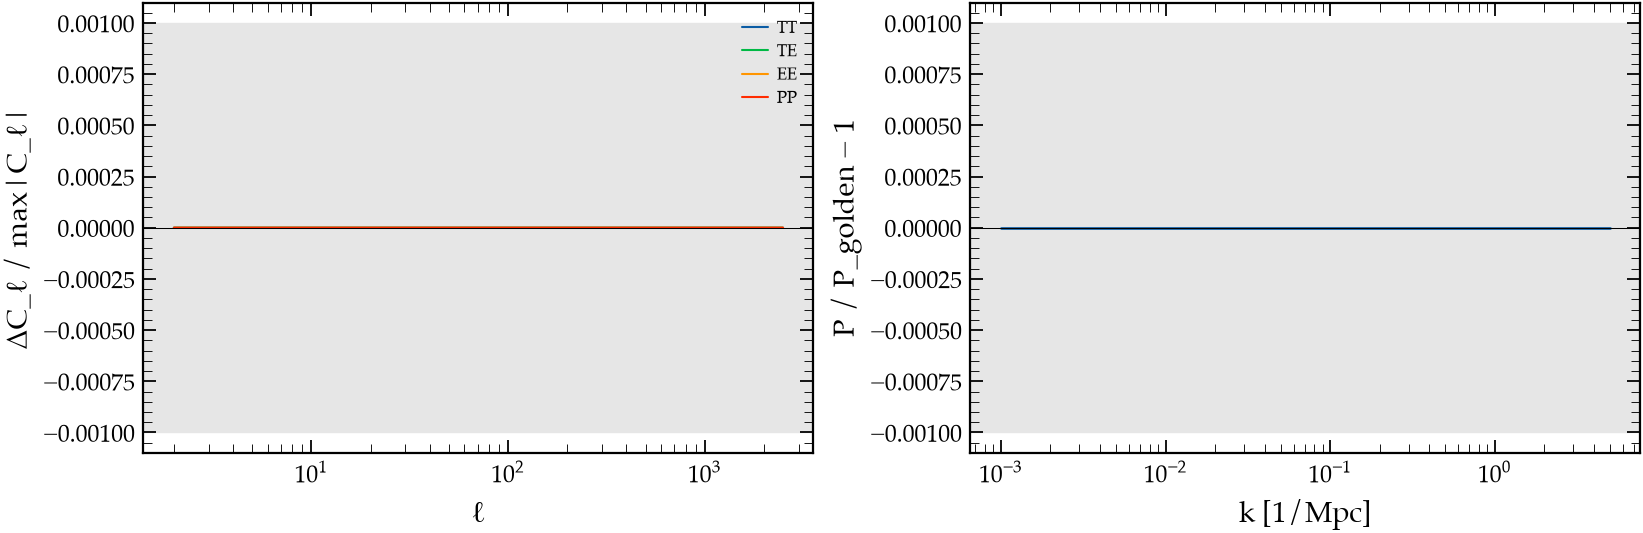

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for s in ('cl_tt', 'cl_te', 'cl_ee', 'cl_pp'):
    axes[0].plot(result['ell'][ell2], (result[s] - ref[s])[ell2]/np.max(np.abs(ref[s])), lw=1, label=s[3:].upper())
axes[0].set_xscale('log')
axes[0].set_xlabel('ℓ')
axes[0].set_ylabel('ΔC_ℓ / max|C_ℓ|')
axes[0].legend(fontsize=8)
axes[1].semilogx(K_NODES, result['pk']/ref['pk'] - 1)
axes[1].set_xlabel('k [1/Mpc]')
axes[1].set_ylabel('P / P_golden − 1')
for ax, tol in zip(axes, (TOL['cl'], TOL['pk'])):
    ax.axhspan(-tol, tol, color='0.9', zorder=0)
    ax.axhline(0, color='k', lw=0.5)
plt.show()